In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os ; import re
from astropy.convolution import Gaussian1DKernel, convolve
from pathlib import Path
from lib_QMout import *
from scipy.interpolate import CubicSpline
from sympy.physics.wigner import wigner_3j
from lib_QMout import *


In [2]:
base_dir=Path("/home/jorgebdelafuente/Doctorado/Photoion/SHARC/PH/Get_Dy/")

folders = [f for f in base_dir.iterdir() if f.is_dir() and f.name.startswith("ICOND")]

def extract_number(path):
    return int(path.name.split('_')[1])
folders_sorted = sorted(folders, key=extract_number) 

In [3]:
def gethmat (data,stts):
    start_readE=False
    e_mat=np.zeros((stts,stts),dtype=complex)
    nsts=""+str(stts)+" "+str(stts)

    i=0
    for line in data:
        if "Hamiltonian Matrix" in line:
            start_readE=True
            continue
        if start_readE:
            if nsts in line:
                continue
            elif line.strip() == "":
                break
            else:
                parts = list(map(float, line.split()))
                # parts tiene longitud 2*stts
                for j in range(stts):
                    real = parts[2*j]
                    imag = parts[2*j + 1]
                    e_mat[i, j] = real + 1j*imag
                i += 1
    return e_mat

def getDy(data,stts):
    dymat=np.zeros((stts,stts),dtype=complex)

    start_read=False
    tmcoord=0
    nts=""+str(stts)+" "+str(stts)

    i=0
    for line in data:
        if "Dipole Moment Matrices" in line:
            start_read=True
            continue

        if start_read:
            if nts in line:
                tmcoord+=1
                continue
            if tmcoord==1:
                parts = list(map(float, line.split()))
                for j in range(stts):
                    real = parts[2*j]
                    imag = parts[2*j + 1]
                    dymat[i, j] = real + 1j*imag
                i += 1
            elif tmcoord==2:
                break
                
    return dymat

def dysmat_SOC(dyvect,nOmPH,nOmPHM):
    dys_N_C1 = dyvect[:]
    dysmat_N_C1 = np.zeros((dyvect.shape[0],dyvect.shape[0]))

    for i in range(dyvect.shape[0]):
            dysmat_N_C1[i][i] = dys_N_C1[i]

    return rvals,dysmat_N_C1

def getgeom(data):
    start_read=False
    for i,line in enumerate(data):
        if i==0:
            nat=int(data[0])
            xyz=np.zeros((nat,3))
        elif i==1:
            start_read=True
            natom=0
            continue
        if start_read and natom<nat:
            parts=line.split()
            for k in range(3):
                xyz[natom,k] = parts[k+1]
            natom+=1
    
    for i in range(nat-1):
        for j in range(i,nat):
            rdist=np.sqrt((xyz[i,0]-xyz[j,0])**2+(xyz[i,1]-xyz[j,1])**2+(xyz[i,2]-xyz[j,2])**2)

    return rdist



/home/jorgebdelafuente/miniconda3/envs/gnrl_env/lib/python3.13/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/jorgebdelafuente/miniconda3/envs/gnrl_env/lib/python3.13/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


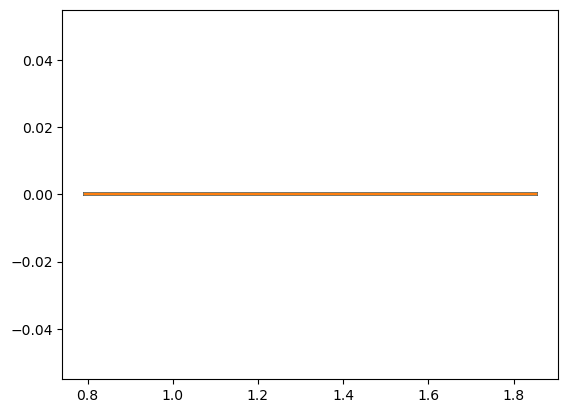

In [4]:
ic0 = str(folders_sorted[0])+"/QM.out"
datic0 = read_qmout(ic0)
total_stts,stts = getNstates(datic0)

hmat=np.zeros((len(folders_sorted),total_stts,total_stts),dtype=complex)
hmatv2=np.zeros((len(folders_sorted),total_stts,total_stts),dtype=complex)
dyson_el=np.zeros((len(folders_sorted),total_stts,total_stts),dtype=complex)
rdist=np.zeros((len(folders_sorted)))

for i,folder in enumerate(folders_sorted):
    ic = str(folder)+"/QM.out"
    inp = str(folder)+"/QM.in"
    datic = read_qmout(ic)
    datin = read_qmout(inp)
    hmat[i,:,:] = gethmat(datic,total_stts)
    # dymat[i,:,:] = getDy(datic,total_stts)
    rdist[i] = getgeom(datin)
    
for i in range(len(folders_sorted)):
    QMoutfile = str(folder)+"/QM.out"
    QMinfile = str(folder)+"/QM.in"

    outdat=read_qmout(QMoutfile)
    indat=read_qmout(QMinfile)

    total_stts,stts=getNstates(outdat)
    dyson=read_Dyson(outdat,total_stts)

    for j in range(total_stts):
        row=dyson[j]
        for k in range(total_stts):
            re=row[2*k]
            im=row[2*k+1]
            dyson_el[i][j][k]=re+1j*im

order=np.argsort(rdist)
r_sorted=rdist[order]
dyson_sorted=dyson_el[order,:,:]
hmat_sorted=hmat[order,:,:]
r_sorted=r_sorted*0.529177

fig, ax = plt.subplots()
for i in range(total_stts):
    # ax.plot(r_sorted,dyson_sorted[:,0,i])
    for j in range(total_stts):
        if i!=j:
            ax.plot(r_sorted,hmat_sorted[:,i,j])


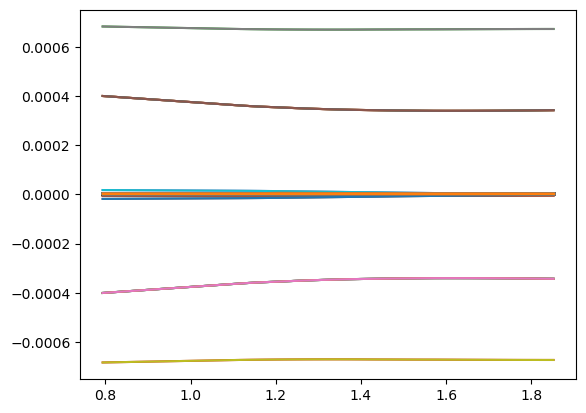

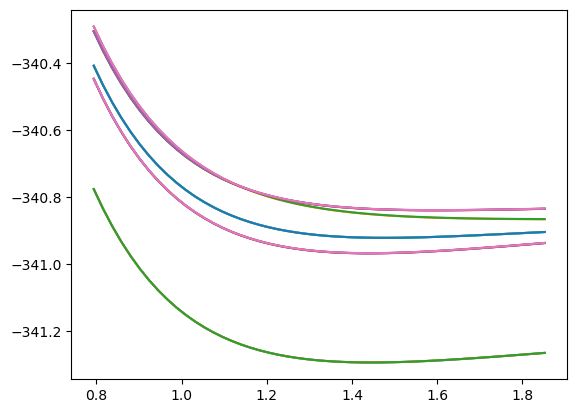

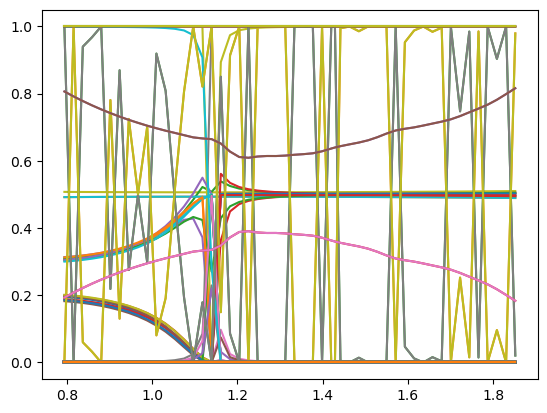

In [5]:
soc_dat = np.loadtxt("/home/jorgebdelafuente/Doctorado/Photoion/DUO/PHPHM/PHM_SOC/Spin-Orbit.dat")
rvals=soc_dat[:,0] ; soc11=soc_dat[:,1]/219474 ; soc44=soc_dat[:,2]/219474 ; soc12=soc_dat[:,3]/219474 ; soc13=soc_dat[:,4]/219474 ; soc14=soc_dat[:,5]/219474 ; soc23=soc_dat[:,6]/219474

soc11spl = CubicSpline(rvals,soc11)
soc44spl = CubicSpline(rvals,soc44)
soc12spl = CubicSpline(rvals,soc12)
soc13spl = CubicSpline(rvals,soc13)
soc14spl = CubicSpline(rvals,soc14)
soc23spl = CubicSpline(rvals,soc23)

for i in range(total_stts-1):
    for j in range(i+1,total_stts):
        if i!=j:
            if (i==0 and j==3) or (i==1 and j==2):
                hmat_sorted[:,i,j].imag=soc11spl(r_sorted)
                hmat_sorted[:,j,i].imag=-soc11spl(r_sorted)
            elif (i==6 and j==9) or (i==7 and j==8):
                hmat_sorted[:,i,j].imag=soc44spl(r_sorted)
                hmat_sorted[:,j,i].imag=-soc44spl(r_sorted)
            elif (i==0 and j==16) or (i==1 and j==14) or (i==2 and j==13) or (i==3 and j==12):
                hmat_sorted[:,i,j].real=soc12spl(r_sorted)
                hmat_sorted[:,j,i].real=soc12spl(r_sorted)
            elif (i==1 and j==4) or (i==2 and j==5):
                hmat_sorted[:,i,j].real=soc13spl(r_sorted)
                hmat_sorted[:,j,i].real=soc13spl(r_sorted)
            elif (i==0 and j==7) or (i==1 and j==6) or (i==1 and j==8) or (i==2 and j==7) or (i==2 and j==9) or (i==3 and j==8):
                hmat_sorted[:,i,j].imag=soc14spl(r_sorted)
                hmat_sorted[:,j,i].imag=-soc14spl(r_sorted)
            elif (i==4 and j==13) or (i==4 and j==15) or (i==5 and j==14) or (i==5 and j==16):
                hmat_sorted[:,i,j].imag=soc23spl(r_sorted)
                hmat_sorted[:,j,i].imag=-soc23spl(r_sorted)

fig1,ax1=plt.subplots()
for i in range(total_stts):
    for j in range(total_stts):
        if i!=j:
            if (hmat_sorted[:,i,j].imag).all!=0:
                ax1.plot(r_sorted,hmat_sorted[:,i,j].imag)
            # ax1.plot(r_sorted,hmat_sorted[:,i,j])

evals,evecs=np.linalg.eigh(hmat_sorted)

fig2,ax2=plt.subplots()
for i in range(total_stts):
    ax2.plot(r_sorted,evals[:,i])
    # ax2.plot(r_sorted,hmat_sorted[:,i,i])

fig3,ax3=plt.subplots()
# for i in range(total_stts):
#     for j in range(total_stts):
#         ax3.plot(r_sorted,np.sqrt(evecs[:,i,j].real**2+evecs[:,i,j].imag**2))

dysoc = np.zeros((len(folders_sorted),total_stts,total_stts),dtype=complex)
for i in range(len(folders_sorted)):
    U = evecs[i,:,:]
    dysoc[i,:,:]=U.conj().T @ dyson_sorted[i,:,:] @ U

for i in range(total_stts):
    for j in range(total_stts):
        if i!=j:
            ax3.plot(r_sorted,np.abs(evecs[:, i, j])**2)

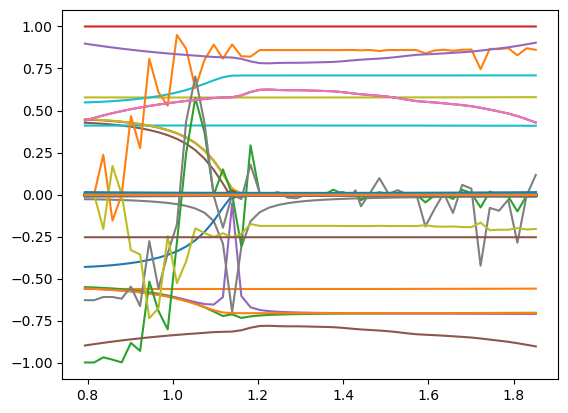

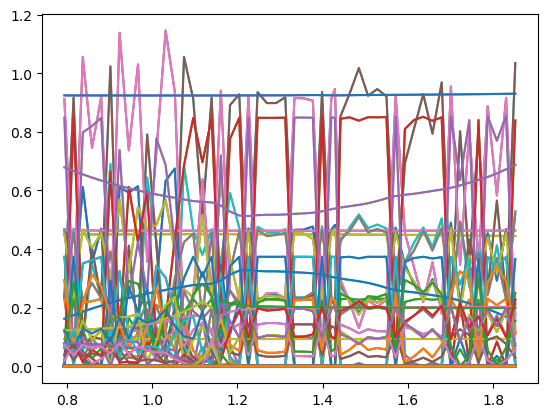

In [26]:
import numpy as np
from scipy.optimize import linear_sum_assignment

def smooth_evecs(evecs):
    """
    evecs shape: (Nr, N, N)
    evecs[k,:,j] = autovector j en el punto k
    """
    Nr, N, _ = evecs.shape
    V = evecs.copy()

    for k in range(1, Nr):
        Vprev = V[k-1, :, :]      # (N,N)
        Vcur  = V[k,   :, :]

        # matriz de solapes |<prev_i | cur_j>|
        S = np.abs(Vprev.conj().T @ Vcur)

        # asignación óptima (maximizar diagonal)
        row_ind, col_ind = linear_sum_assignment(-S)
        Vcur = Vcur[:, col_ind]

        # alineación de fase estado por estado
        for j in range(N):
            ov = np.vdot(Vprev[:, j], Vcur[:, j])  # <prev|cur>
            if np.abs(ov) > 0:
                Vcur[:, j] *= np.exp(-1j * np.angle(ov))

        V[k, :, :] = Vcur

    return V

# uso:
evals, evecs = np.linalg.eigh(hmat_sorted)
evecs_s = smooth_evecs(evecs)

# plot poblaciones de un estado
j = 0
fig, ax = plt.subplots()
for i in range(total_stts):
    for j in range(total_stts):
        if i!=j:
            # ax.plot(r_sorted, np.abs(evecs_s[:, i, j])**2)
            ax.plot(r_sorted, (evecs_s[:, i, j]))

dysoc = np.zeros((len(folders_sorted),total_stts,total_stts),dtype=complex)
for i in range(len(folders_sorted)):
    U = evecs[i,:,:]
    dysoc[i,:,:]=U.conj().T @ dyson_sorted[i,:,:] @ U
    # dysoc[i,:,:]= U.conj().T @ U

fig, ax = plt.subplots()
for i in range(total_stts):
    for j in range(total_stts):
        if i!=j:
            # ax.plot(r_sorted, np.abs(evecs_s[:, i, j])**2)
            ax.plot(r_sorted, np.abs(dysoc[:, i, j])**2)


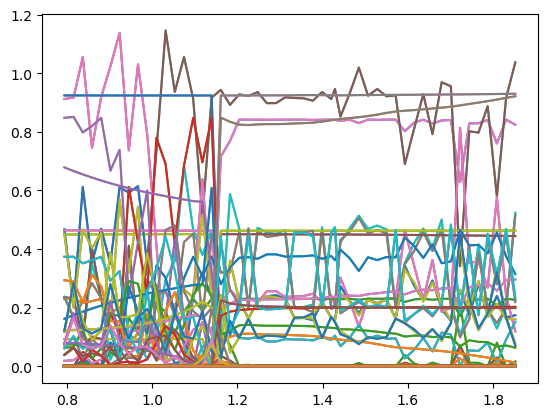

In [28]:
import numpy as np
from scipy.optimize import linear_sum_assignment

def get_permutation_from_overlap(V_ref, V_new):
    """
    V_ref: (N,N) autovectores referencia (columnas = estados)
    V_new: (N,N) autovectores nuevos

    Devuelve:
        perm : array de tamaño N tal que
            V_new[:, perm] corresponde al orden de V_ref
    """

    # matriz de solapes
    S = np.abs(V_ref.conj().T @ V_new)

    # matching óptimo (maximizar solape total)
    row_ind, col_ind = linear_sum_assignment(-S)

    # perm[j] = índice en V_new que corresponde al estado j de V_ref
    perm = col_ind

    return perm

def reorder_evecs_along_r(evecs):
    Nr, N, _ = evecs.shape
    V = evecs.copy()

    perms = []

    for k in range(1, Nr):
        perm = get_permutation_from_overlap(V[k-1], V[k])
        V[k] = V[k][:, perm]
        perms.append(perm)

    return V, perms

import numpy as np
from scipy.optimize import linear_sum_assignment

# ============================================================
# 1) Diagonalización punto a punto
# ============================================================

evals, evecs = np.linalg.eigh(hmat_sorted)
# evals: (Nr, N)
# evecs: (Nr, N, N)  columnas = estados


# ============================================================
# 2) Función para obtener permutación óptima por solape
# ============================================================

def get_permutation_from_overlap(V_ref, V_new):
    S = np.abs(V_ref.conj().T @ V_new)
    row_ind, col_ind = linear_sum_assignment(-S)
    return col_ind


# ============================================================
# 3) Tracking + fase + reordenamiento Dyson
# ============================================================

Nr, N = evals.shape

evecs_tracked = evecs.copy()
evals_tracked = evals.copy()
dyson_tracked = dyson_sorted.copy()

for k in range(1, Nr):

    V_prev = evecs_tracked[k-1]
    V_cur  = evecs_tracked[k]

    # ---- obtener permutación
    perm = get_permutation_from_overlap(V_prev, V_cur)

    # ---- aplicar permutación
    evecs_tracked[k] = V_cur[:, perm]
    evals_tracked[k] = evals_tracked[k, perm]

    # ---- reordenar Dyson en la MISMA forma
    dyson_tracked[k] = dyson_tracked[k][np.ix_(perm, perm)]

    # ---- corrección de fase (gauge continuo)
    for j in range(N):
        ov = np.vdot(evecs_tracked[k-1][:, j], evecs_tracked[k][:, j])
        if np.abs(ov) > 0:
            phase = np.exp(-1j * np.angle(ov))
            evecs_tracked[k][:, j] *= phase


# ============================================================
# 4) Transformar Dyson a base adiabática consistente
# ============================================================

dysoc = np.zeros_like(dyson_tracked, dtype=complex)

for k in range(Nr):
    U = evecs_tracked[k]
    dysoc[k] = U.conj().T @ dyson_tracked[k] @ U

fig, ax = plt.subplots()
for i in range(total_stts):
    for j in range(total_stts):
        if i!=j:
            # ax.plot(r_sorted, np.abs(evecs_s[:, i, j])**2)
            ax.plot(r_sorted, np.abs(dysoc[:, i, j])**2)
